In [1]:
import requests
import pandas as pd

# Stooq provides free, direct CSV downloads - no signup needed
url = "https://stooq.com/q/d/l/?s=aapl.us&i=d"

response = requests.get(url)
response.encoding = "utf-8"

# Save the raw CSV to our folder
with open("aapl_stock.csv", "w", encoding="utf-8") as f:
    f.write(response.text)

# Load it into pandas
df = pd.read_csv("aapl_stock.csv")

print("Shape:", df.shape)
print(df.head())
print(df.tail())

Shape: (0, 1)
Empty DataFrame
Columns: [<meta charset=utf-8><title>Stooq</title><center style=font-family:arial;margin-top:50px><p><a href=/><img src=//static.stooq.com/stooq.svg height=68></a><p style=font-size:x-large>The page you requested does not exist<br>or has been moved<p><small><a href=/>Main Page</a>]
Index: []
Empty DataFrame
Columns: [<meta charset=utf-8><title>Stooq</title><center style=font-family:arial;margin-top:50px><p><a href=/><img src=//static.stooq.com/stooq.svg height=68></a><p style=font-size:x-large>The page you requested does not exist<br>or has been moved<p><small><a href=/>Main Page</a>]
Index: []


In [2]:
import numpy as np
import pandas as pd

# For reproducibility - same random numbers every time we run this
np.random.seed(42)

# Create 3 years of daily dates
dates = pd.date_range(start="2022-01-01", end="2024-12-31", freq="D")
n = len(dates)

# 1. TREND: sales slowly grow over time (a gentle upward line)
trend = np.linspace(100, 200, n)

# 2. SEASONALITY: a repeating yearly wave (higher in Nov/Dec, lower mid-year)
day_of_year = dates.dayofyear
seasonality = 20 * np.sin(2 * np.pi * day_of_year / 365)

# 3. NOISE: small random day-to-day variation
noise = np.random.normal(0, 5, n)

# Combine all three into our final "sales" numbers
sales = trend + seasonality + noise

# Build our DataFrame
df = pd.DataFrame({"Date": dates, "Sales": sales})
df.set_index("Date", inplace=True)

print("Shape:", df.shape)
print(df.head())
print(df.tail())

Shape: (1096, 1)
                 Sales
Date                  
2022-01-01  102.827838
2022-01-02  100.088435
2022-01-03  104.453484
2022-01-04  109.265170
2022-01-05  100.913826
                 Sales
Date                  
2024-12-27  198.416199
2024-12-28  202.675743
2024-12-29  199.732814
2024-12-30  203.571876
2024-12-31  199.940684


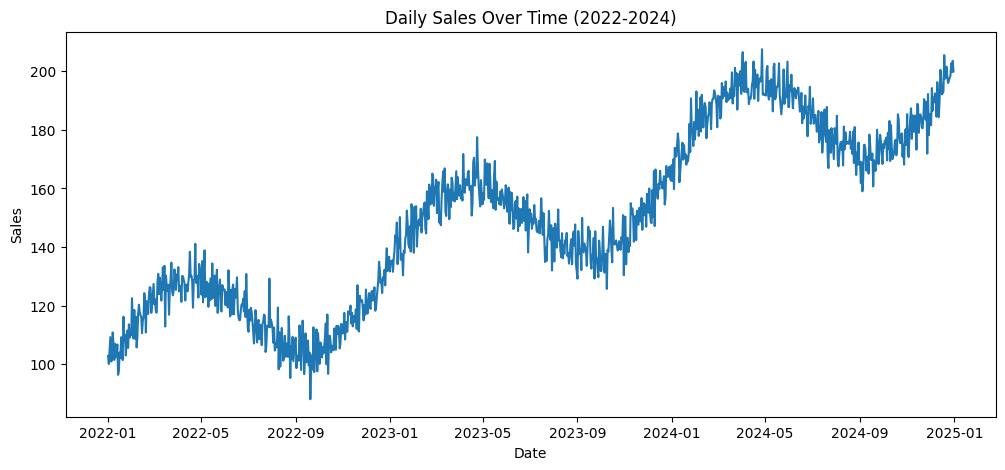

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Sales"])
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales Over Time (2022-2024)")
plt.savefig("raw_sales.png", dpi=150, bbox_inches="tight")
plt.show()

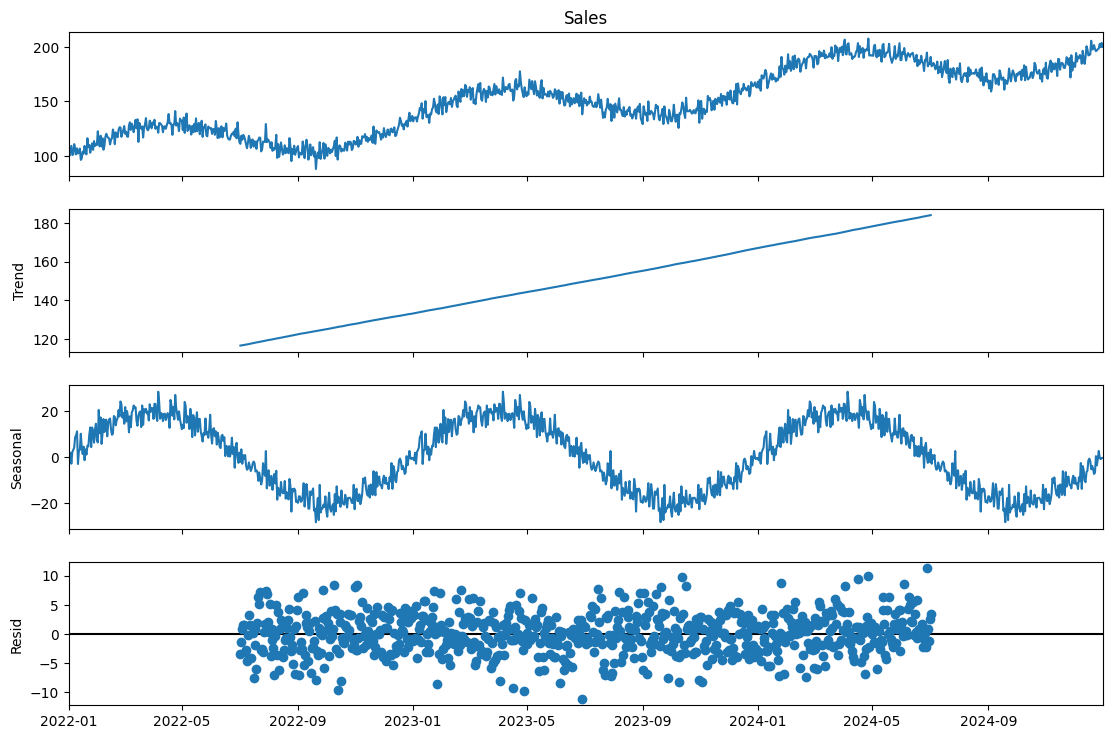

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

# period=365 tells it "look for a repeating pattern every 365 days" (yearly)
decomposition = seasonal_decompose(df["Sales"], model="additive", period=365)

# Plot all 4 pieces: original, trend, seasonal, residual
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.savefig("decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

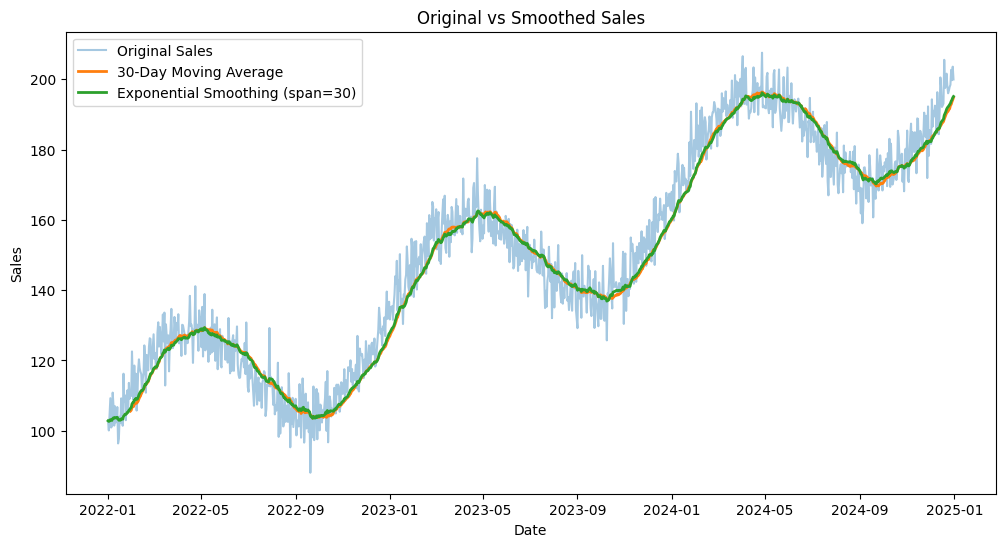

In [6]:
# Moving Average: average of the last 30 days, sliding forward each day
df["Moving_Avg_30"] = df["Sales"].rolling(window=30).mean()

# Exponential Smoothing: recent days weighted more heavily
df["Exp_Smooth"] = df["Sales"].ewm(span=30, adjust=False).mean()

# Plot all three together for comparison
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Sales"], label="Original Sales", alpha=0.4)
plt.plot(df.index, df["Moving_Avg_30"], label="30-Day Moving Average", linewidth=2)
plt.plot(df.index, df["Exp_Smooth"], label="Exponential Smoothing (span=30)", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Original vs Smoothed Sales")
plt.legend()
plt.savefig("smoothing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Split into training (first 2.5 years) and testing (last 6 months)
train = df["Sales"][:-180]
test = df["Sales"][-180:]

# Build the SARIMA model
# order=(1,1,1) handles the regular AR-I-MA part
# seasonal_order=(1,1,1,365) handles the yearly seasonal pattern
model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 365))
model_fit = model.fit(disp=False)

print(model_fit.summary())

In [8]:
# Resample our daily data into weekly data (averaging each 7-day block)
df_weekly = df["Sales"].resample("W").mean()

print("Original daily rows:", len(df))
print("Weekly rows:", len(df_weekly))
print(df_weekly.head())

Original daily rows: 1096
Weekly rows: 158
Date
2022-01-02    101.458136
2022-01-09    105.074291
2022-01-16    102.428040
2022-01-23    107.259110
2022-01-30    108.815250
Freq: W-SUN, Name: Sales, dtype: float64


In [9]:
# Split into training and testing (last 26 weeks = about 6 months for testing)
train_weekly = df_weekly[:-26]
test_weekly = df_weekly[-26:]

print("Training weeks:", len(train_weekly))
print("Testing weeks:", len(test_weekly))

# Build the SARIMA model - now with a MUCH lighter seasonal period (52 weeks = 1 year)
model = SARIMAX(train_weekly, order=(1, 1, 1), seasonal_order=(1, 1, 1, 52))
model_fit = model.fit(disp=False)

print("Model trained successfully!")

Training weeks: 132
Testing weeks: 26


C:\Users\USER-PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


Model trained successfully!


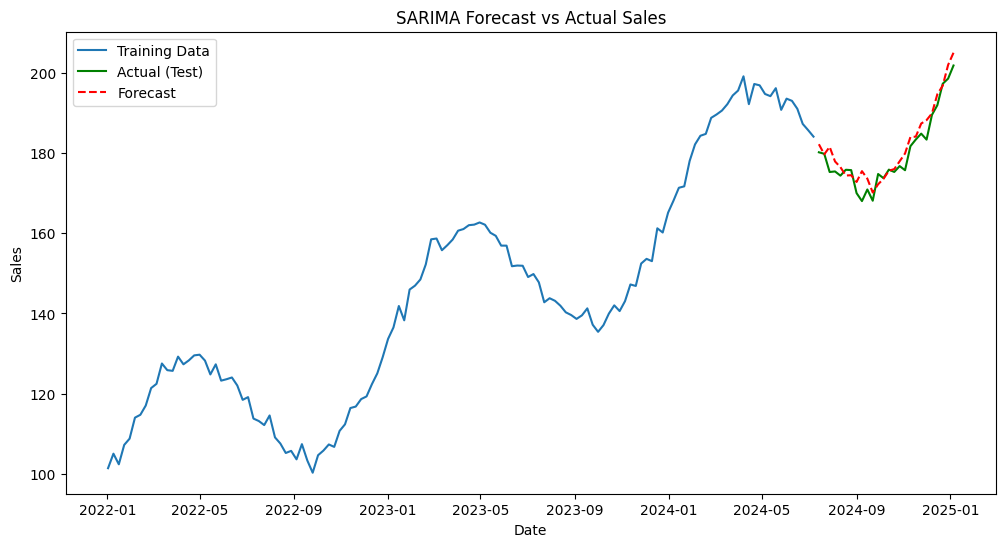

In [10]:
# Forecast the same number of weeks as our test set
forecast = model_fit.forecast(steps=len(test_weekly))

# Plot actual vs forecasted
plt.figure(figsize=(12, 6))
plt.plot(train_weekly.index, train_weekly, label="Training Data")
plt.plot(test_weekly.index, test_weekly, label="Actual (Test)", color="green")
plt.plot(test_weekly.index, forecast, label="Forecast", color="red", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("SARIMA Forecast vs Actual Sales")
plt.legend()
plt.savefig("sarima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_weekly, forecast))
print("RMSE:", rmse)

RMSE: 2.9316911073243515
